In [1]:
import jax
from jax.config import config
config.update("jax_enable_x64", True)
import jax.numpy as np
import zodiax as zdx
import dLux as dl
import optax

import matplotlib.pyplot as plt

In [2]:
# from jax.typing import Array, ArrayLike
Array = jax.numpy.ndarray
from abc import abstractmethod
from jax import vmap
from jax.tree_util import tree_map
from equinox import tree_at
from dLux.core import Instrument
from typing import Any
import dLux

class AbstractObservation(zdx.ExtendedBase):
    name : str

    def __init__(self, name='AbstractObservation'):
        self.name = str(name)
    
    @abstractmethod
    def observe(self, instrument) -> Any:
        pass


class Dither(AbstractObservation):
    dithers : Array


    def __init__(self, dithers, name='Observation'):
        super().__init__(name)
        self.dithers = np.asarray(dithers, float)


    def dither_position(self, instrument : Instrument, dither : Array) -> Instrument:
        """
        Dithers the position of the source objects by dither.

        Parameters
        ----------
        dither : Array, radians
            The (x, y) dither to apply to the source positions.

        Returns
        -------
        instrument : Instrument
            The instrument with the sources dithered.
        """
        assert dither.shape == (2,), ("dither must have shape (2,) ie (x, y)")

        # Define the dither function
        dither_fn = lambda source: source.add('position', dither)

        # Map the dithers across the sources
        dithered_sources = tree_map(dither_fn, instrument.scene.sources, \
                is_leaf = lambda leaf: isinstance(leaf, dLux.sources.Source))

        # Apply updates
        return tree_at(lambda instrument: instrument.scene.sources, instrument, \
                       dithered_sources)


    def dither_and_model(self,
                         instrument : Instrument,
                         dithers : Array,
                         **kwargs) -> Any:
        """
        Applies a series of dithers to the instrument sources and calls the
        .model() method after applying each dither.

        Parameters
        ----------
        dithers : Array, radians
            The array of dithers to apply to the source positions.

        Returns
        -------
        psfs : Array
            The psfs generated after applying the dithers to the source
            positions.
        """
        dith_fn = lambda dither: self.dither_position(instrument, dither).model(**kwargs)
        return vmap(dith_fn, 0)(dithers)
    

    def observe(self, instrument):
        return self.dither_and_model(instrument, self.dithers)
    
    def _construct():
        return Dither(np.array([]))

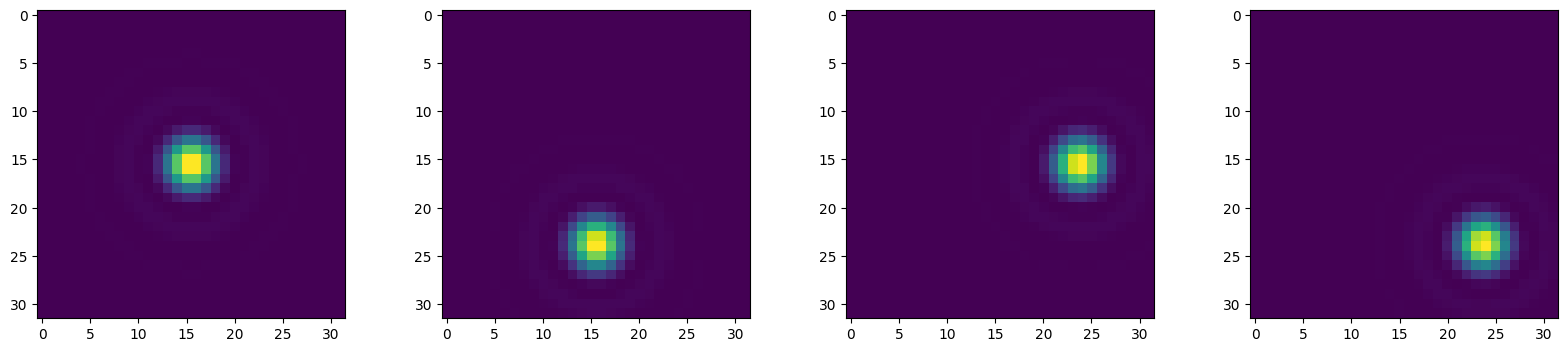

In [3]:
source = dl.PointSource(wavelengths=[1e-6])
optics = dl.utils.simple_optical_system(1, 256, 32, 5e-2)

x = 2e-6
obs = Dither(dithers=np.array([[0, 0], [0, x], [x, 0], [x, x]]))
tel = dl.Instrument(optics, sources=[source], observation=obs)

plt.figure(figsize=(20, 4))
psfs = tel.observe()
for i in range(len(psfs)):
    plt.subplot(1, 4, i+1)
    plt.imshow(psfs[i])
plt.show()

In [4]:
@zdx.filter_jit
@zdx.filter_value_and_grad('dithers')
def loss_fn(model, data):
    return np.sum((model.observe() - data)**2)

In [5]:
model = tel.add('dithers', 5e-7)
loss, grads = loss_fn(model, psfs)

In [6]:
import equinox as eqx
optim = optax.adam(1e-3)
opt_state = optim.init(eqx.filter(model, eqx.is_array))

In [7]:
optim, opt_state = model.get_optimiser(['dithers'], [optax.adam(1e-7)])

losses = []
for i in range(100):
    loss, grads = loss_fn(model, psfs)
    updates, opt_state = optim.update(grads, opt_state)
    model = model.apply_updates(updates)
    losses.append(loss)

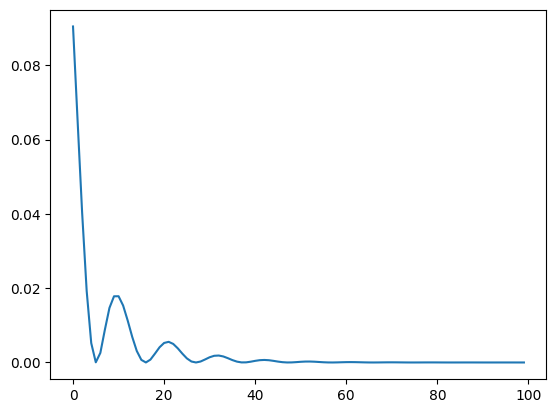

In [8]:
plt.plot(losses)

In [9]:
import zodiax
# from collections import OrderedDict
from jax.typing import ArrayLike
import numpy

def check_node(obj      : Any, 
               self_key : str  = None, 
               depth    : int  = 0., 
               _print   : bool = False) -> bool:
    """
    Checks if the input object is a container or a leaf node. If the object is
    a leaf a tuple of (False, obj) is returned. If the object is a container
    a tuple of (True, (obj, keys, accessor)) is returned. The accessor is 
    require to handle the different getter methods for dictionaries, lists, 
    objects etc. Also checks that object containter types have the required
    `_construct()` method required for deserilisation. It does not check that
    the `_construct()` method is valid, this is required to be done by the
    user.

    Container types:
        list, tuple, dict, zodiax.Base
    
    Leaf types:
        ArrayLike, bool, complex, float, int, numpy.ndarray, str, None

    Parameters
    ----------
    obj : Any
        The object to check.
    depth : int = 0
        The depth of the object in the tree. Use to print the tree structure
        for debugging.
    self_key : str = None
        The key of the object in the parent container. Use to print the tree
        structure for debugging.
    _print : bool = False
        If True, print the tree structure for debugging.
    
    Returns
    -------
    (is_container, node) : tuple
        is_container : bool
            True if the object is a container, False if it is a leaf.
        node : tuple
            If is_container is True, the node is a tuple of (obj, keys, 
            accessor). If is_container is False, the node is the object itself.
    """
    t = '  ' * depth
    conatiner_types = (list, tuple, dict, zodiax.Base)
    leaf_types = (ArrayLike, bool, complex, float, int, str, type(None))

    # Contianer node
    if isinstance(obj, conatiner_types):
        if _print: print(f"{t}Node '{self_key}' of type: {type(obj)}")
        return True

    # Leaf node
    elif isinstance(obj, leaf_types):
        if _print: print(f"{t}Leaf '{self_key}' of type: {type(obj)}")
        return False

    # Unknown - Raise error
    else:
        raise ValueError(f"Unknown node '{self_key}' of type: {type(obj)}")
    

def get_accessor(obj : Any) -> tuple:
    """
    Returns the keys and accessor for the input object.

    Parameters
    ----------
    obj : Any
        The object to get the keys and accessor for.

    Returns
    -------
    (keys, accessor) : tuple
        keys : list
            The keys of the object.
        accessor : function
            The accessor function for the object.
    """
    accessor = lambda object, x: object[x]

    # Lists and tuples
    if isinstance(obj, (list, tuple)):
        keys = list(range(len(obj)))
        return keys, accessor

    # Zodaix object types
    elif isinstance(obj, zodiax.Base):
        if not hasattr(obj, '_construct'):
            raise ValueError(f"Object '{obj}' must have a `_construct()` "
                "method that instanitates the class and takes no inputs.")
        
        accessor = lambda object, x: getattr(object, x)
        keys = obj.__dataclass_fields__.keys()
        return keys, accessor

    # Dictionary types
    else:
        return obj.keys(), accessor


def format_type(obj : Any) -> str:
    """
    Returns a string of the object type with the extra '< class ' and '>' 
    removed.

    Parameters
    ----------
    obj : Any
        The object to get the type of.
    
    Returns
    -------
    type_str : str
        The string of the object type.
    """
    class_str = str(type(obj))
    return class_str[class_str.find("'")+1:class_str.rfind("'")]


def format_dtype(dtype : numpy.dtype) -> str:
    """
    Formats the array dtype into a string. Supports boolean, integer, float 
    and complex types.

    Parameters
    ----------
    dtype : numpy.dtype
        The array dtype.
    
    Returns
    -------
    dtype_str : str
    """
    kind_map = {'b': 'bool', 'f': 'float', 'i': 'int', 'c': 'complex'}
    return f"{kind_map[dtype.kind]}{8*dtype.itemsize}"

In [10]:
def build_structure(obj      : Any, 
                    self_key : str  = None, 
                    depth    : int  = 0,
                    _print   : bool = False):
    """
    Recursively iterates over the input object in order to return a dictionary 
    detailing the strucutre of the of the object. Each node can be either a
    conainter node or leaf node. Each node is a dictionary with the following
    structure:

    {'node_type': 'container' or 'leaf',
     'type': str,
     'node': {
        param1 : {'node_type' : 'container', ...}, -> If container
        param2 : {'node_type' : 'leaf',
                  '...' : ...}, -> If leaf where '...' conatins any leaf metadata
        }
    
    Specific leaf metadata:
        Strings:
            String values are stored in the 'value' key and serialised via the
            json
        Jax/Numpy Arrays:
            Both the array shape and dtype are stored in the 'shape' and
            'dtype' keys respectively. 
    
    This method can be developed further to support more leaf types, since each
    individual leaf type can be made to store any arbitrarity metadata, as long
    as it can be serialised by json and used to deserialise it later.
    
    This dictionary can then be serialised using json and then later
    used to deserialise the object in conjunction with equinox leaf 
    serialise/deserialise methods.

    NOTE: In order for the deseriaslisation proccess to be automated, all 
    class instances must have a `_construct()` method which instantiates an
    'empty' instance of th class, which can then be populated with the
    deserialised parameters.

    NOTE: This method is not equipped to handle `equinox.static_field()` 
    parameters, as they can be arbitrary data types but do not get serialised
    by the  `equinox.serialise_tree_leaves()` methods and hence require custom 
    serialisation via this method. Therefore this method currently does not
    handle this case correctly. This is not checked for currently so will
    silently break or result in unexpected behaviour.

    TODO: Serialise package versions in order to raise warnings when 
    deserialising about inconsistent versions.

    Parameters
    ----------
    obj : Any
        The object to get the leaves of.
    self_key : str = None
        The key of the object in the parent container. Use to print the tree
        structure for debugging.
    depth : int = 0
        The depth of the object in the tree. Use to print the tree structure
        for debugging.
    _print : bool = False
        If True, print the tree structure for debugging.
    
    Returns
    -------
    structure : dict
        The dictionary detailing the structure of the object.
    """
    if depth == 0 and not isinstance(obj, zodiax.Base):
        raise ValueError("Input object must be a `zodiax` object.")

    structure = {}
    is_container = check_node(obj, self_key, depth, _print=_print)

    # Recursive case
    if is_container:
        keys, accessor = get_accessor(obj)

        # Iterate over parameters
        for key in keys:
            sub_obj = accessor(obj, key)
            structure[key] = build_node(sub_obj, key, depth, _print)
                    
        # Deal with outermost container
        if depth == 0:
            return build_conatiner_node(obj, structure)
        else:
            return structure

    # Base case    
    else:
        return obj
    

def build_node(obj    : Any, 
               key    : str  = None, 
               depth  : int  = 0, 
               _print : bool = False) -> dict:
    """
    Builds a node for the input object.

    Parameters
    ----------
    obj : Any
        The object to get the leaves of.
    key : str
        The key of the object in the parent container. Use to print the tree
        structure for debugging.
    depth : int
        The depth of the object in the tree. Use to print the tree structure
        for debugging.
    _print : bool
        If True, print the tree structure for debugging.
    
    Returns
    -------
    node_dict : dict
        The dictionary detailing the type and metadata of the node.
    """
    inner_structure = build_structure(obj, key, depth+1, _print)

    # Container node
    if isinstance(inner_structure, dict):
        return build_conatiner_node(obj, inner_structure)

    # Leaf node
    else:
        return build_leaf_node(obj)
    

def build_leaf_node(obj : Any) -> dict:
    """
    Builds a leaf node for the input object.

    Parameters
    ----------
    obj : Any
        The object to get the leaves of.
    
    Returns
    -------
    node_dict : dict
        The dictionary detailing the type and metadata of the leaf.
    """
    # Basic info
    node_dict = {'node_type': 'leaf', 
                 'type': format_type(obj)}
    
    # Handle string case
    if isinstance(obj, str):
        node_dict['value'] = obj
    
    # Append meta-data for arrays
    elif isinstance(obj, (jax.Array, numpy.ndarray)):
        node_dict['shape'] = obj.shape
        node_dict['dtype'] = format_dtype(obj.dtype)
    
    return node_dict


def build_conatiner_node(obj : Any, inner_structure : dict) -> dict:
    """
    Builds a container node for the input object.

    Parameters
    ----------
    obj : Any
        The object to build the container node for.
    inner_structure : dict
        The dictionary detailing the structure of the object.

    Returns
    -------
    node_dict : dict
        The dictionary detailing the type and metadata of the container.
    """
    return {'node_type': 'container', 
            'type': format_type(obj), 
            'node': inner_structure}

import pickle as p
def serialise(path, obj):
    """
    Serialises the input object to the input path.

    Parameters
    ----------
    path : str
        The path to serialise the object to.
    obj : Any
        The object to serialise.
    """
    structure = build_structure(obj)
    with open(path, 'wb') as f:
        p.dump(structure, f)
        eqx.tree_serialise_leaves(f, obj)


In [16]:
object.__setattr__(tel, 'detector', 'test')

In [17]:
tel

Instrument(
  optics=Optics(
    layers={
      'CreateWavefront':
      CreateWavefront(
        name='CreateWavefront',
        npixels=256,
        diameter=f64[],
        wavefront_type='Angular'
      ),
      'CircularAperture':
      StaticAperture(name='CircularAperture', aperture=f64[256,256]),
      'NormaliseWavefront':
      NormaliseWavefront(name='NormaliseWavefront'),
      'AngularMFT':
      AngularMFT(
        name='AngularMFT',
        inverse=False,
        npixels_out=32,
        pixel_scale_out=f64[],
        shift=f64[2],
        pixel_shift=False
      )
    }
  ),
  scene=Scene(
    sources={
      'PointSource':
      PointSource(
        position=f64[2],
        flux=f64[],
        spectrum=ArraySpectrum(
          name='ArraySpectrum',
          wavelengths=f64[1],
          weights=f64[1]
        ),
        name='PointSource'
      )
    }
  ),
  detector='test',
  filter=None,
  observation=Dither(name='Observation', dithers=f64[4,2])
)

In [22]:
class Foo(zodiax.Base):
    # name : str = eqx.static_field()
    name : str

    def __init__(self, name):
        self.name = name

foo = Foo(1, 2, 'test')

In [25]:
class Foo(zodiax.Base):
    name : str

    def __init__(self):
        self.name = 'Foo'

foo = Foo()
object.__setattr__(foo, 'name', 'Bar')
print(foo)

Foo(name='Bar')


In [11]:
serialise("tel.zdx", tel)

structure = build_structure(tel, _print=True)
# json.dump(structure, open("structure.json", 'w'))
# eqx.tree_serialise_leaves("tel.eqx", tel)

Node 'None' of type: <class 'dLux.core.Instrument'>
  Node 'optics' of type: <class 'dLux.core.Optics'>
    Node 'layers' of type: <class 'collections.OrderedDict'>
      Node 'CreateWavefront' of type: <class 'dLux.optics.CreateWavefront'>
        Leaf 'name' of type: <class 'str'>
        Leaf 'npixels' of type: <class 'int'>
        Leaf 'diameter' of type: <class 'jaxlib.xla_extension.Array'>
        Leaf 'wavefront_type' of type: <class 'str'>
      Node 'CircularAperture' of type: <class 'dLux.apertures.StaticAperture'>
        Leaf 'name' of type: <class 'str'>
        Leaf 'aperture' of type: <class 'jaxlib.xla_extension.Array'>
      Node 'NormaliseWavefront' of type: <class 'dLux.optics.NormaliseWavefront'>
        Leaf 'name' of type: <class 'str'>
      Node 'AngularMFT' of type: <class 'dLux.propagators.AngularMFT'>
        Leaf 'name' of type: <class 'str'>
        Leaf 'inverse' of type: <class 'bool'>
        Leaf 'npixels_out' of type: <class 'int'>
        Leaf 'pixel

In [13]:
cls = None

cls.__new__(cls)

TypeError: NoneType.__new__(X): X is not a type object (NoneType)

In [15]:
eval('None') == None

True

In [12]:
object.__setattr__?

Signature:      object.__setattr__(self, name, value, /)
Call signature: object.__setattr__(*args, **kwargs)
Type:           wrapper_descriptor
String form:    <slot wrapper '__setattr__' of 'object' objects>
Namespace:      Python builtin
Docstring:      Implement setattr(self, name, value).